# **Assignment 10**

**Name : Shantanu Kaute | Prn.no: 1252090007 | roll.no:07**

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS

1)Apply Linear Regression using a suitable library function and predict the Month-wise temperature.

3)Assess the performance of regression models using MSE, MAE and R-Square   
4)metrics



5)Visualize a simple regression model.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('temperatures.csv')
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57


# **Data Preprocessing**

In [ ]:
print(df.isnull().sum())
df = df.dropna()
print(df.info())

YEAR       0
JAN        0
FEB        0
MAR        0
APR        0
MAY        0
JUN        0
JUL        0
AUG        0
SEP        0
OCT        0
NOV        0
DEC        0
ANNUAL     0
JAN-FEB    0
MAR-MAY    0
JUN-SEP    0
OCT-DEC    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     117 non-null    int64  
 1   JAN      117 non-null    float64
 2   FEB      117 non-null    float64
 3   MAR      117 non-null    float64
 4   APR      117 non-null    float64
 5   MAY      117 non-null    float64
 6   JUN      117 non-null    float64
 7   JUL      117 non-null    float64
 8   AUG      117 non-null    float64
 9   SEP      117 non-null    float64
 10  OCT      117 non-null    float64
 11  NOV      117 non-null    float64
 12  DEC      117 non-null    float64
 13  ANNUAL   117 non-null    float64
 14  JAN-FEB  117 non-null    float64
 1

# **Convert Month to Numeric**

In [ ]:
df_long = pd.melt(df,
                  id_vars=['YEAR'],
                  value_vars=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],
                  var_name='Month',
                  value_name='Temperature')

df_long.head()

,YEAR,Month,Temperature
0,1901,JAN,22.40
1,1902,JAN,24.93
2,1903,JAN,23.44
3,1904,JAN,22.50
4,1905,JAN,22.00


# **Convert Month to Numeric**

In [ ]:
month_map = {
    'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
    'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12
}

df_long['Month'] = df_long['Month'].map(month_map)

# **Feature Selection**

In [ ]:
X = df_long[['Month']]
y = df_long['Temperature']

# **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Apply Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# **Model Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 9.999806682283973
MAE: 2.705271869781447
R2 Score: -0.005573628993982727


# **Visualization**

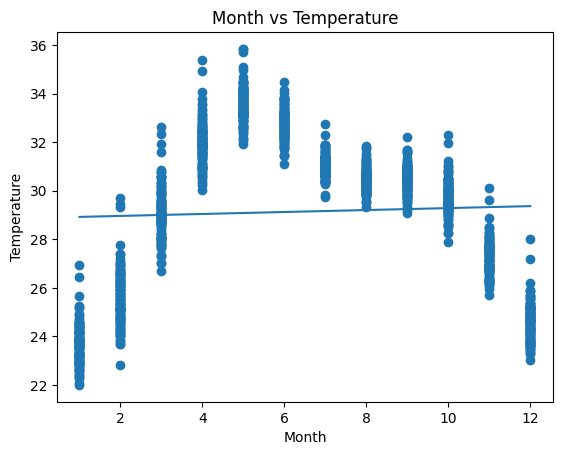

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, model.predict(X))

plt.title("Month vs Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()